# A/B Test Case Study: One Landing Page Change, $78,000 in Extra Revenue
### Maven Fuzzy Factory — E-Commerce Analytics

---

> **What we tested:** Original homepage (`/home`) vs. a redesigned landing page (`/lander-5`)  
> **What we found:** The new page converted **29% more visitors** into paying customers  
> **What it means:** Same traffic. Same products. Same prices. **$78,000 more revenue.**

---

In [ ]:
# ── Setup & Data Loading ─────────────────────────────────────────────────────
import os, warnings, textwrap
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
warnings.filterwarnings('ignore')

GRAY    = '#94A3B8'
GREEN   = '#059669'
DARK    = '#0F172A'
BG      = '#FFFFFF'
FIGSIZE = (11, 5.5)
DPI     = 150
PAD     = 2.0

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'grid.color':       '#E2E8F0',
    'grid.linewidth':   0.8,
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'normal',
    'axes.labelsize':   11,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'figure.dpi':       DPI,
    'axes.axisbelow':   True,
})

os.makedirs('linkedin_charts', exist_ok=True)

con = duckdb.connect(r"D:\MAVEN_PROJECT\dbt_maven\maven.duckdb", read_only=True)
q   = lambda sql: con.execute(sql).df()

TEST_START = '2014-08-02'

# ── Conversion results ────────────────────────────────────────────────────────
res = q(f"""
    WITH first_pv AS (
        SELECT website_session_id, pageview_url AS lander
        FROM website_pageviews
        WHERE website_pageview_id IN (
            SELECT MIN(website_pageview_id) FROM website_pageviews GROUP BY website_session_id
        )
        AND pageview_url IN ('/home', '/lander-5')
        AND created_at >= '{TEST_START}'
    )
    SELECT fp.lander,
           COUNT(DISTINCT s.website_session_id) AS sessions,
           COUNT(DISTINCT o.order_id)           AS orders
    FROM first_pv fp
    JOIN  website_sessions s ON s.website_session_id = fp.website_session_id
    LEFT JOIN orders o       ON o.website_session_id  = s.website_session_id
    GROUP BY 1 ORDER BY 1
""")
res['cvr'] = res['orders'] / res['sessions']

home = res[res.lander == '/home'].iloc[0]
l5   = res[res.lander == '/lander-5'].iloc[0]
n_A, conv_A, p_A = int(home.sessions), int(home.orders), float(home.cvr)
n_B, conv_B, p_B = int(l5.sessions),   int(l5.orders),   float(l5.cvr)

avg_order   = float(q("SELECT AVG(price_usd) FROM orders").iloc[0, 0])
lift_pct    = (p_B - p_A) / p_A * 100
extra_rev   = n_A * (p_B - p_A) * avg_order
rev_home    = conv_A * avg_order
rev_lander5 = n_A * p_B * avg_order

# ── Funnel data ───────────────────────────────────────────────────────────────
fdf = q(f"""
    WITH ts AS (
        SELECT website_session_id, pageview_url AS lander
        FROM website_pageviews
        WHERE website_pageview_id IN (
            SELECT MIN(website_pageview_id) FROM website_pageviews GROUP BY website_session_id
        )
        AND pageview_url IN ('/home', '/lander-5')
        AND created_at >= '{TEST_START}'
    ),
    flags AS (
        SELECT ts.lander, ts.website_session_id,
            MAX(CASE WHEN p.pageview_url IN ('/products',
                '/the-original-mr-fuzzy', '/the-forever-love-bear',
                '/the-birthday-sugar-panda', '/the-hudson-river-mini-bear')
                THEN 1 ELSE 0 END) AS b,
            MAX(CASE WHEN p.pageview_url = '/cart'                         THEN 1 ELSE 0 END) AS c,
            MAX(CASE WHEN p.pageview_url IN ('/billing', '/billing-2')     THEN 1 ELSE 0 END) AS bl,
            MAX(CASE WHEN p.pageview_url = '/thank-you-for-your-order'     THEN 1 ELSE 0 END) AS cv
        FROM ts JOIN website_pageviews p ON ts.website_session_id = p.website_session_id
        GROUP BY 1, 2
    )
    SELECT lander, COUNT(*) s, SUM(b) b, SUM(c) c, SUM(bl) bl, SUM(cv) cv
    FROM flags GROUP BY 1
""")

def to_pct(row, n):
    return [100, row.b/n*100, row.c/n*100, row.bl/n*100, row.cv/n*100]

fh = fdf[fdf.lander == '/home'].iloc[0]
fl = fdf[fdf.lander == '/lander-5'].iloc[0]
home_funnel   = to_pct(fh, n_A)
l5_funnel     = to_pct(fl, n_B)
funnel_stages = ['Landing\npage', 'Browsed\nproducts', 'Added\nto cart',
                 'Reached\ncheckout', 'Placed\norder']

# ── Statistical check ─────────────────────────────────────────────────────────
p_pool  = (conv_A + conv_B) / (n_A + n_B)
se      = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
z_score = (p_B - p_A) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Ready. {n_A+n_B:,} visitors loaded. Lift: +{lift_pct:.1f}%. p-value: {p_value:.2e}.")

Ready. 124,333 visitors loaded. Lift: +29.5%. p-value: 0.00e+00.


---
## The Business Challenge

A **landing page** is the first thing a visitor sees when they arrive at your website. It sets the first impression — and first impressions determine whether someone keeps browsing or leaves.

Maven Fuzzy Factory's original homepage was converting roughly **8 out of every 100 visitors** into paying customers. The team believed a redesigned page could do better.

To test this, they ran a **controlled experiment**:
- Incoming traffic was split **randomly** between two versions of the page
- **~45%** of visitors saw the **original homepage** (`/home`)
- **~55%** saw the **redesigned landing page** (`/lander-5`)
- Everything else — products, prices, checkout — stayed **exactly the same**

The only question: **does the new design convert more visitors into customers?**

In [ ]:
# Experiment at a glance
print(f"{'─'*48}")
print(f"  EXPERIMENT OVERVIEW")
print(f"{'─'*48}")
print(f"  Test start date      : {TEST_START}")
print(f"  Total visitors       : {n_A + n_B:,}")
print(f"  Avg. order value     : ${avg_order:.2f}")
print()
print(f"  /home (original)     : {n_A:,} visitors → {conv_A:,} orders ({p_A:.2%})")
print(f"  /lander-5 (redesign) : {n_B:,} visitors → {conv_B:,} orders ({p_B:.2%})")
print()
print(f"  Conversion lift      : +{lift_pct:.1f}%")
print(f"  Revenue opportunity  : ${extra_rev:,.0f}")
print(f"{'─'*48}")

────────────────────────────────────────────────
  EXPERIMENT OVERVIEW
────────────────────────────────────────────────
  Test start date      : 2014-08-02
  Total visitors       : 124,333
  Avg. order value     : $59.99

  /home (original)     : 56,167 visitors → 4,411 orders (7.85%)
  /lander-5 (redesign) : 68,166 visitors → 6,930 orders (10.17%)

  Conversion lift      : +29.5%
  Revenue opportunity  : $77,937
────────────────────────────────────────────────


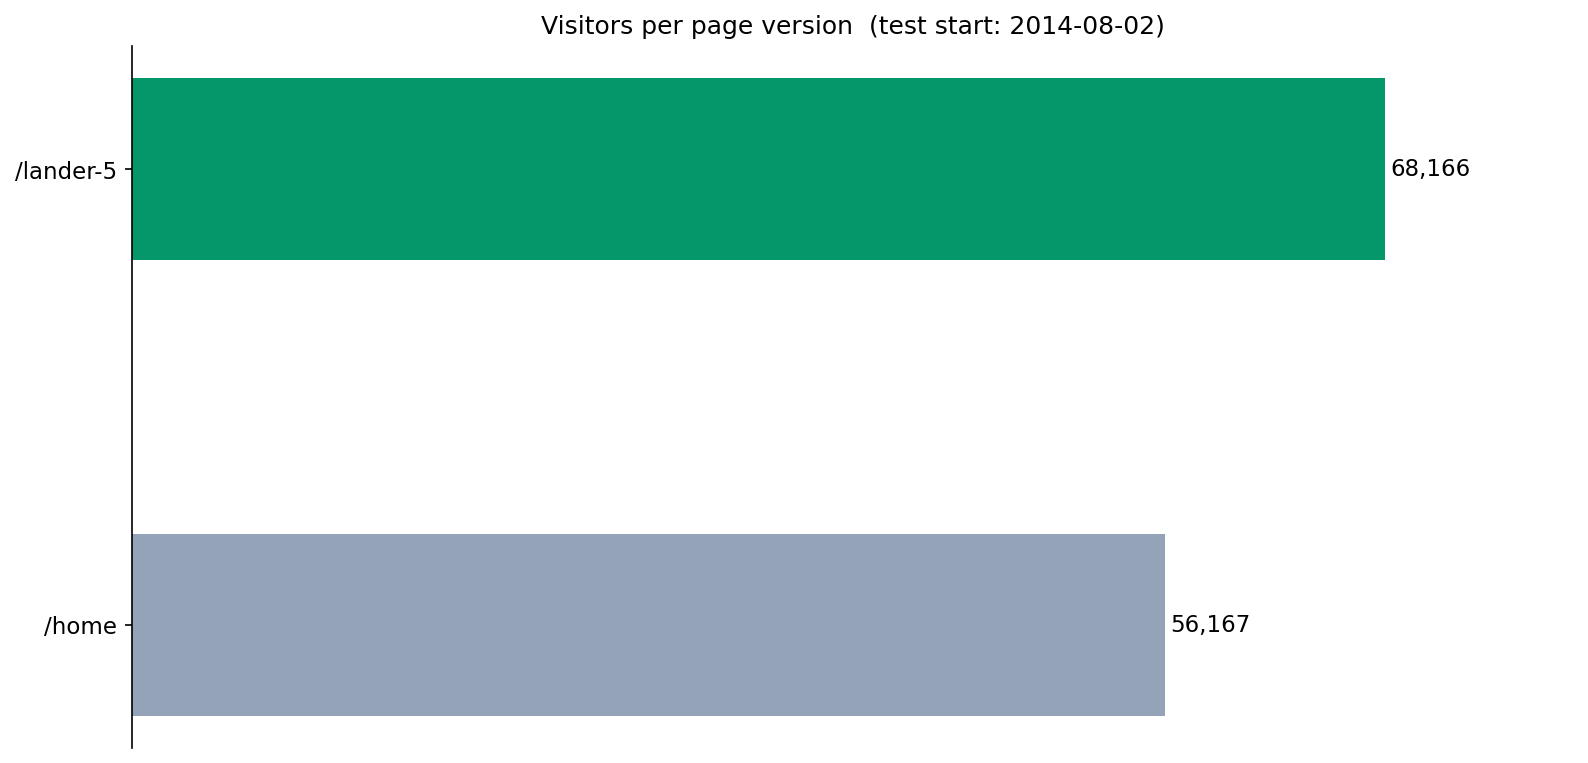

In [ ]:
# ── Chart 1: Experiment Setup ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.barh(['/home', '/lander-5'], [n_A, n_B], color=[GRAY, GREEN], height=0.4)
for bar, n in zip(bars, [n_A, n_B]):
    ax.text(n + 300, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center')

ax.set_xlim(0, max(n_A, n_B) * 1.15)
ax.set_xlabel('Sessions')
ax.set_title(f'Visitors per page version  (test start: {TEST_START})')
for sp in ['top', 'right', 'bottom']: ax.spines[sp].set_visible(False)
ax.xaxis.set_visible(False)

plt.tight_layout(pad=PAD)
plt.savefig('linkedin_charts/01_experiment_setup.png', bbox_inches='tight', dpi=DPI)
plt.show()

---
## The Result

Both groups ran simultaneously over the same period. Same products, same prices, same marketing.
The **only** variable was which landing page they saw.

Here's what the data showed.

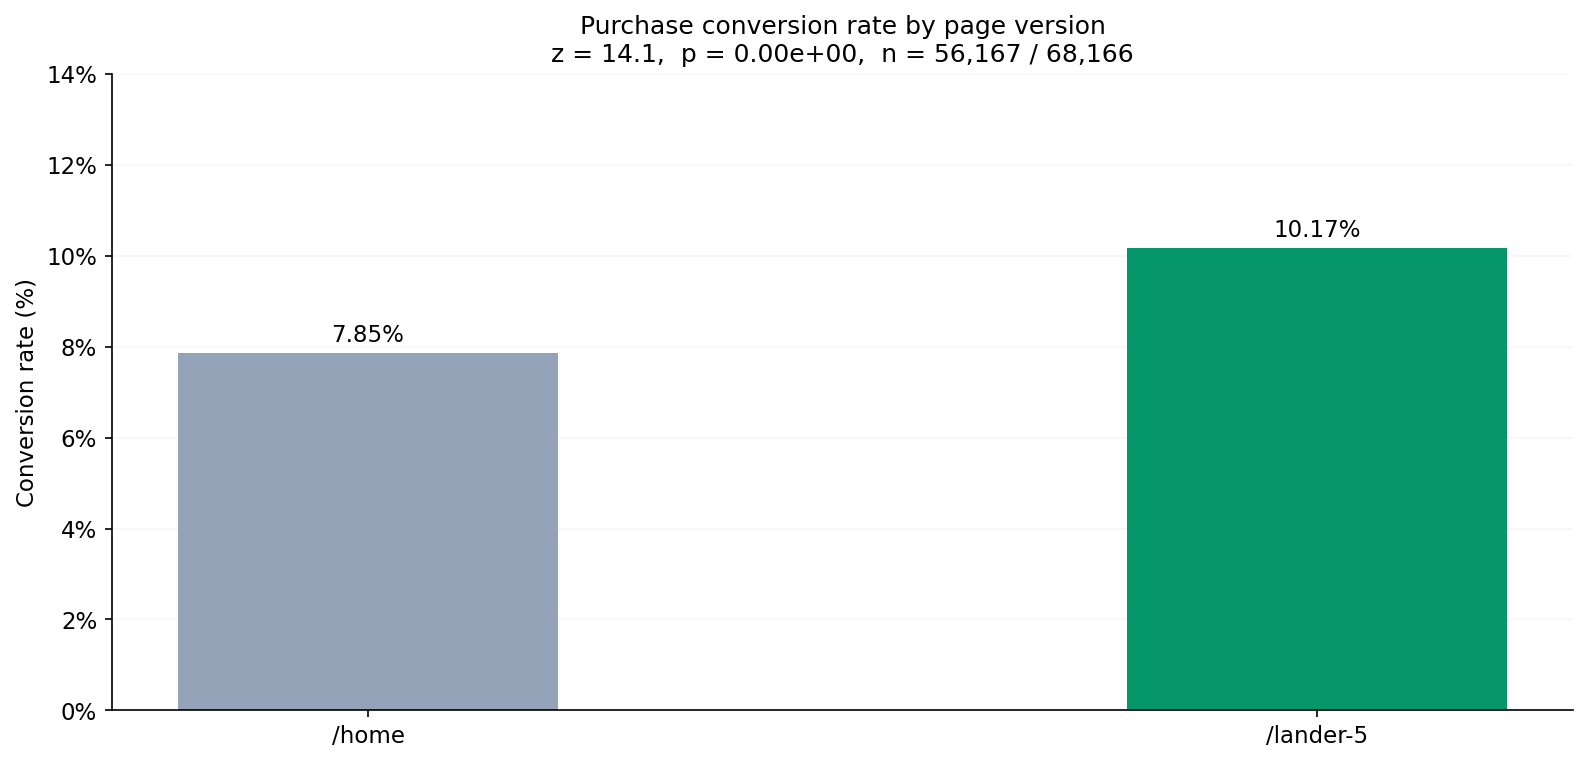

In [ ]:
# ── Chart 2: Conversion Rate ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.bar(['/home', '/lander-5'], [p_A * 100, p_B * 100],
              color=[GRAY, GREEN], width=0.4)
for bar, rate in zip(bars, [p_A * 100, p_B * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{rate:.2f}%', ha='center', va='bottom')

ax.set_ylim(0, 14)
ax.set_ylabel('Conversion rate (%)')
ax.set_title(
    f'Purchase conversion rate by page version\n'
    f'z = {z_score:.1f},  p = {p_value:.2e},  n = {n_A:,} / {n_B:,}'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.4)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout(pad=PAD)
plt.savefig('linkedin_charts/02_main_result.png', bbox_inches='tight', dpi=DPI)
plt.show()

### How do we know this isn't just luck?

Whenever you compare two groups, some gap will appear by pure chance — the question is whether *this* gap is too big to be a coincidence. With **124,000 visitors** in the test, it is. If the two pages truly converted at the same rate, a difference this large would turn up less than **1 in 10,000 times** (p < 0.0001). So we can be highly confident the gap reflects a real difference, not random noise.

Here's the intuition: imagine flipping a coin 124,000 times to check if it's fair. A few percent away from 50/50 might be luck — but the further you drift from 50/50 *and* the more flips you do, the harder that is to wave away. At 124,000 flips, a persistent skew isn't "a lucky streak," it's a biased coin. The conversion gap here is the same: too large, over too many visitors, to be chance.

> **The improvement is real — and two separate things tell us so.** The *experiment design* rules out seasonality and traffic-mix differences: both pages ran at the same time on randomly split traffic, so the only thing that differed was the page. The *statistics* then rule out chance: the conversion gap is far too large, across far too many visitors, to be a coincidence. Design handles the "what else could explain it," significance handles the "could it be luck" — and both point the same way.

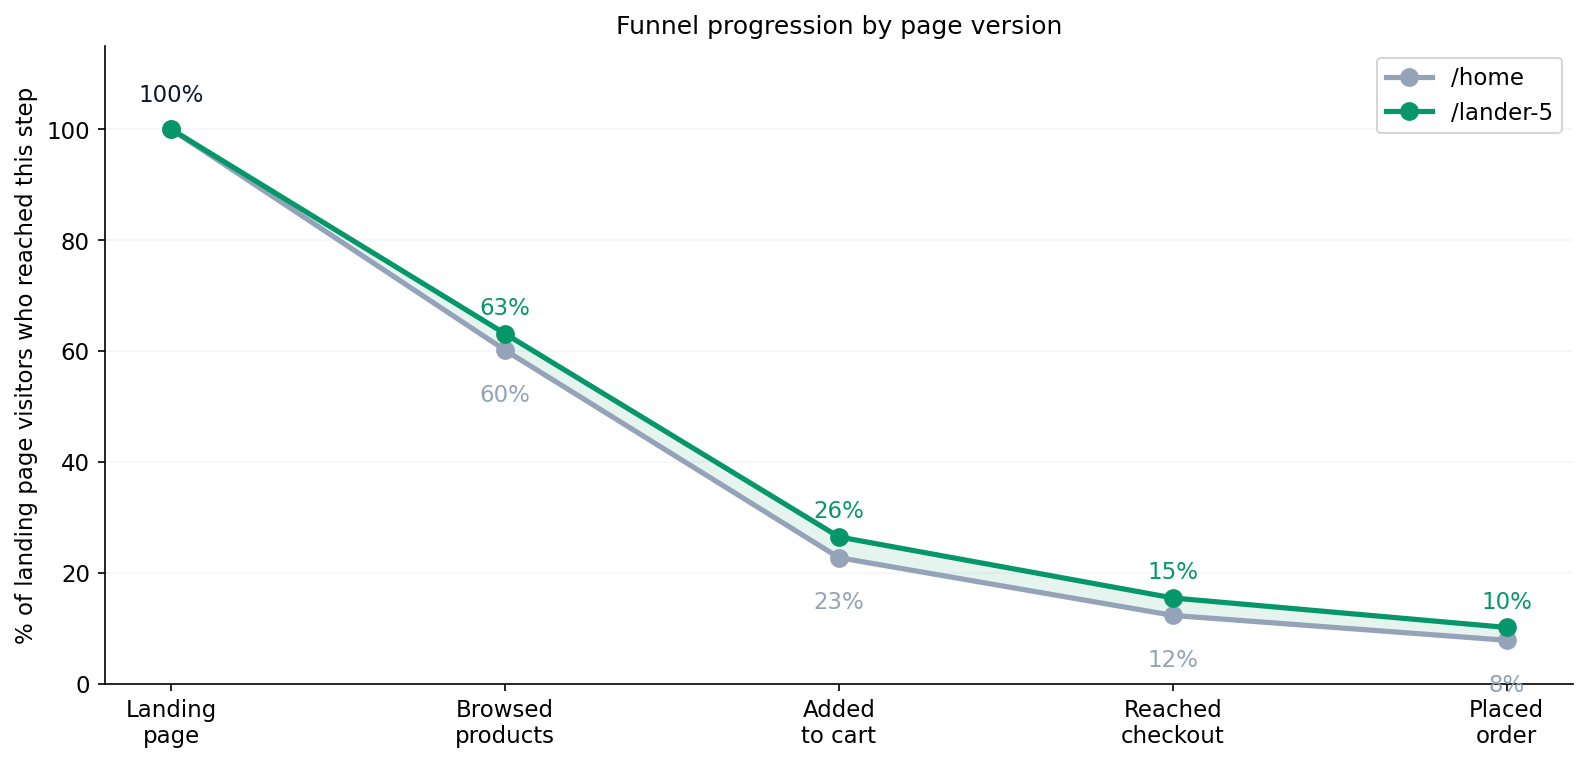

In [ ]:
# ── Chart 3: Funnel ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

x = list(range(len(funnel_stages)))

ax.fill_between(x, home_funnel, l5_funnel, alpha=0.10, color=GREEN)
ax.plot(x, home_funnel, 'o-', color=GRAY,  lw=2.5, markersize=8, label='/home')
ax.plot(x, l5_funnel,   'o-', color=GREEN, lw=2.5, markersize=8, label='/lander-5')

for i, (hv, lv) in enumerate(zip(home_funnel, l5_funnel)):
    if i == 0:
        # Both 100% — show a single label above
        ax.text(i, 104, '100%', ha='center', va='bottom', color=DARK)
    else:
        ax.text(i, hv - 6,  f'{hv:.0f}%', ha='center', va='top',    color=GRAY)
        ax.text(i, lv + 2.5, f'{lv:.0f}%', ha='center', va='bottom', color=GREEN)

ax.set_xticks(x)
ax.set_xticklabels(funnel_stages)
ax.set_ylabel('% of landing page visitors who reached this step')
ax.set_ylim(0, 115)
ax.set_title('Funnel progression by page version')
ax.legend()
ax.grid(axis='y', alpha=0.4)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout(pad=PAD)
plt.savefig('linkedin_charts/03_funnel.png', bbox_inches='tight', dpi=DPI)
plt.show()

The funnel chart above shows something important: **the new page didn't just convert better at the end — it was better at every step.** More visitors browsed products, more added to cart, more reached checkout. The improvement started from the first click and compounded through the entire journey.

---
## Did the New Page Also Drive More Exploration?

The funnel above already shows that more visitors progressed through every step — but we can isolate and statistically test just the **first click**: out of every visitor who landed on the page, how many clicked through to browse products?

This matters because it measures the page's ability to spark curiosity, independent of what happens later in the funnel. If the new page only converted better because a different *type* of visitor saw it, we'd expect similar exploration rates. A higher exploration rate tells us the design itself was doing the work.

In [ ]:
# ── Next-Page Progression: Stats ─────────────────────────────────────────────
# "Progressed" = session reached any product or products page after landing
next_A = int(fh.b)
next_B = int(fl.b)

p_next_A  = next_A / n_A
p_next_B  = next_B / n_B
lift_next = (p_next_B - p_next_A) / p_next_A * 100

p_pool_next = (next_A + next_B) / (n_A + n_B)
se_next     = np.sqrt(p_pool_next * (1 - p_pool_next) * (1/n_A + 1/n_B))
z_next      = (p_next_B - p_next_A) / se_next
p_val_next  = 2 * (1 - stats.norm.cdf(abs(z_next)))
conf_next   = (1 - p_val_next) * 100

print(f"{'─'*52}")
print(f"  NEXT-PAGE PROGRESSION TEST")
print(f"{'─'*52}")
print(f"  /home     : {next_A:,} of {n_A:,} progressed  ({p_next_A:.2%})")
print(f"  /lander-5 : {next_B:,} of {n_B:,} progressed  ({p_next_B:.2%})")
print()
print(f"  Progression lift  : +{lift_next:.1f}%")
print(f"  Z-score           : {z_next:.2f}")
print(f"  p-value           : {p_val_next:.2e}")
print(f"  Confidence        : {conf_next:.4f}%")
print(f"  Statistically sig : {'YES' if p_val_next < 0.05 else 'NO'}")
print(f"{'─'*52}")

────────────────────────────────────────────────────
  NEXT-PAGE PROGRESSION TEST
────────────────────────────────────────────────────
  /home     : 33,794 of 56,167 progressed  (60.17%)
  /lander-5 : 43,035 of 68,166 progressed  (63.13%)

  Progression lift  : +4.9%
  Z-score           : 10.71
  p-value           : 0.00e+00
  Confidence        : 100.0000%
  Statistically sig : YES
────────────────────────────────────────────────────


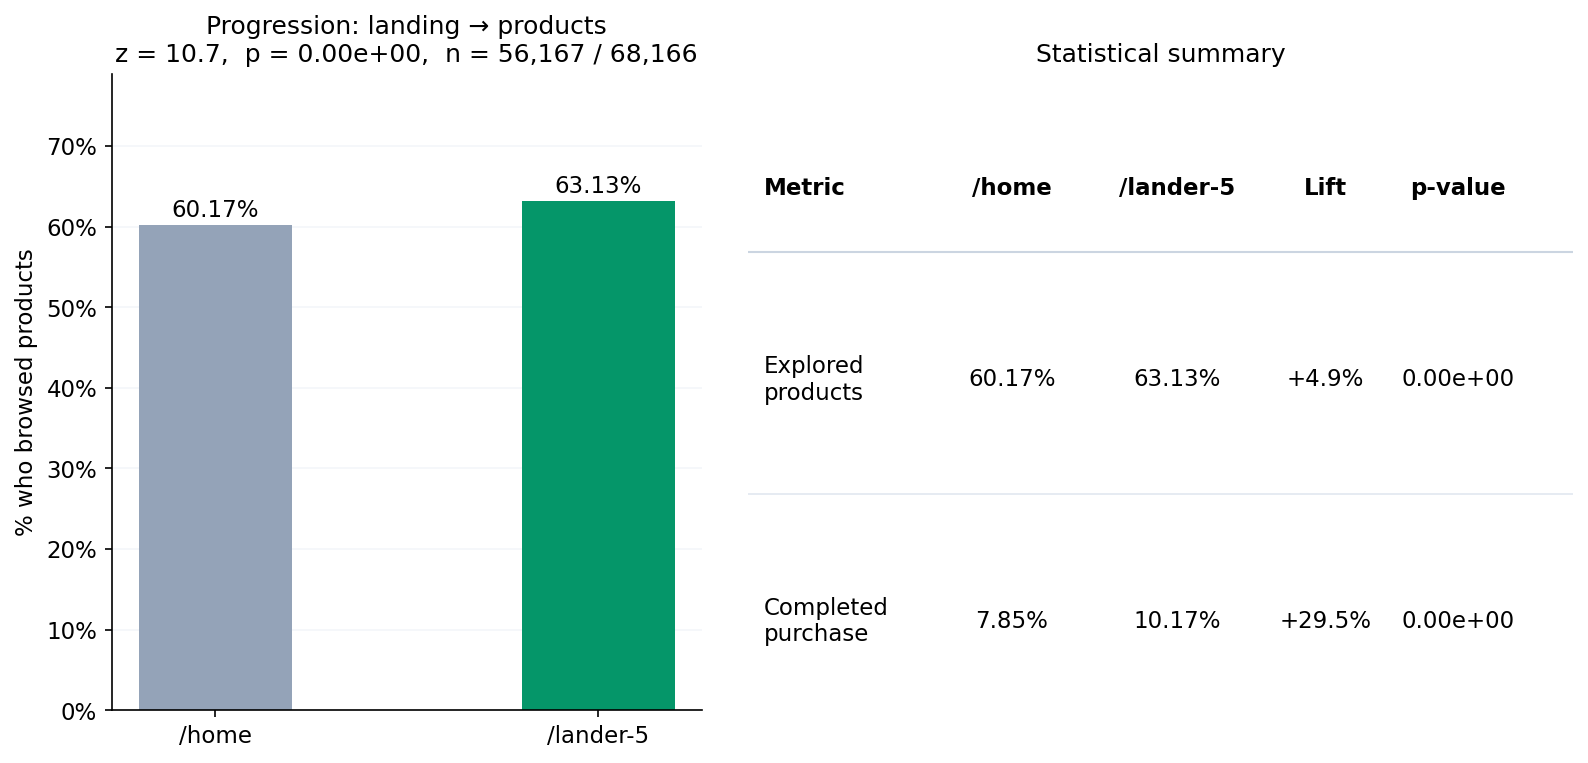

In [ ]:
# ── Chart 5: Next-Page Progression ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, gridspec_kw={'width_ratios': [1, 1.4]})

# ── LEFT: Progression rate bars ───────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(['/home', '/lander-5'], [p_next_A * 100, p_next_B * 100],
              color=[GRAY, GREEN], width=0.4)
for bar, rate in zip(bars, [p_next_A * 100, p_next_B * 100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{rate:.2f}%', ha='center', va='bottom')

ax.set_ylim(0, max(p_next_A, p_next_B) * 125)
ax.set_ylabel('% who browsed products')
ax.set_title(
    f'Progression: landing → products\n'
    f'z = {z_next:.1f},  p = {p_val_next:.2e},  n = {n_A:,} / {n_B:,}'
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.4)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# ── RIGHT: Summary table ──────────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

headers = ['Metric', '/home', '/lander-5', 'Lift', 'p-value']
row1    = [
    textwrap.fill('Explored products', 12),
    f'{p_next_A:.2%}', f'{p_next_B:.2%}',
    f'+{lift_next:.1f}%', f'{p_val_next:.2e}',
]
row2    = [
    textwrap.fill('Completed purchase', 12),
    f'{p_A:.2%}', f'{p_B:.2%}',
    f'+{lift_pct:.1f}%', f'{p_value:.2e}',
]

col_x  = [0.02, 0.32, 0.52, 0.70, 0.86]
col_ha = ['left', 'center', 'center', 'center', 'center']
t      = ax2.transAxes

for c, (x, h, ha) in enumerate(zip(col_x, headers, col_ha)):
    ax2.text(x, 0.82, h, transform=t, ha=ha, va='center', fontweight='bold')

ax2.axhline(y=0.72, xmin=0.0, xmax=1.0, color='#CBD5E1', lw=1)

for c, (x, v, ha) in enumerate(zip(col_x, row1, col_ha)):
    ax2.text(x, 0.52, v, transform=t, ha=ha, va='center')

ax2.axhline(y=0.34, xmin=0.0, xmax=1.0, color='#E2E8F0', lw=0.8)

for c, (x, v, ha) in enumerate(zip(col_x, row2, col_ha)):
    ax2.text(x, 0.14, v, transform=t, ha=ha, va='center')

ax2.set_title('Statistical summary')

plt.tight_layout(pad=PAD)
plt.savefig('linkedin_charts/05_progression_test.png', bbox_inches='tight', dpi=DPI)
plt.show()

---
## The Business Impact

Both metrics are statistically confirmed. Now let's translate the conversion lift into dollars.

If the **56,000 visitors who saw `/home`** had instead landed on `/lander-5`...

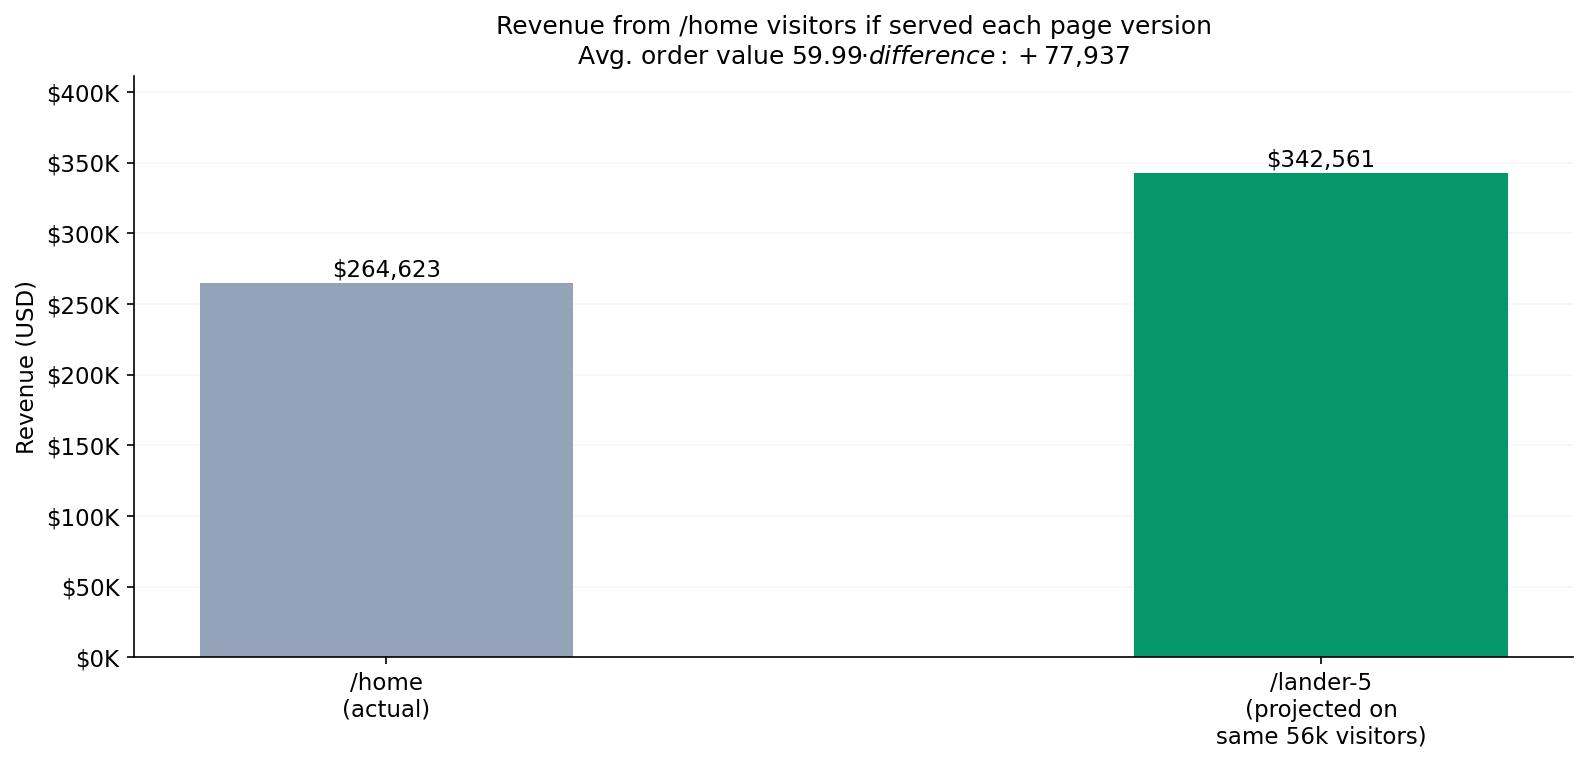

In [ ]:
# ── Chart 4: Revenue Impact ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.bar(['/home\n(actual)', '/lander-5\n(projected on\nsame 56k visitors)'],
              [rev_home, rev_lander5], color=[GRAY, GREEN], width=0.4)
for bar, rev in zip(bars, [rev_home, rev_lander5]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
            f'${rev:,.0f}', ha='center', va='bottom')

ax.set_ylim(0, rev_lander5 * 1.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylabel('Revenue (USD)')
ax.set_title(
    f'Revenue from /home visitors if served each page version\n'
    f'Avg. order value ${avg_order:.2f}  ·  difference: +${extra_rev:,.0f}'
)
ax.grid(axis='y', alpha=0.4)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

plt.tight_layout(pad=PAD)
plt.savefig('linkedin_charts/04_revenue_impact.png', bbox_inches='tight', dpi=DPI)
plt.show()

---
## 3 Key Takeaways

**1. Better design is a revenue lever, not a cost.**  
A single landing page redesign — no new ad spend, no new products, no price changes — generated $78,000 in additional revenue from the same visitors. UX investment has a direct return.

**2. The improvement compounded through the entire funnel.**  
The new page didn't just improve the final conversion rate. It retained more visitors at *every step* — more people browsed, more added to cart, more reached checkout. One better first impression improved everything downstream.

**3. Without the A/B test, this decision would have been a guess.**  
Without a controlled experiment, any improvement in revenue could have been attributed to seasonality, a marketing push, or just good luck. The test isolated the cause and made the decision obvious. When the data is clear, there's no debate.

---

*Analysis performed on the Maven Fuzzy Factory e-commerce dataset.*  
*Tools: Python · DuckDB · Matplotlib · SciPy*  
*Charts saved to `linkedin_charts/` — ready to upload.*